In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [3]:
car_dataset = pd.read_csv('/content/car data.csv')

In [4]:
car_dataset.head(3)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0


In [5]:
car_dataset.shape

(301, 9)

In [6]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
car_dataset.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [8]:
car_dataset.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
print('\nFuel Type:')
print(car_dataset['Fuel_Type'].value_counts())
print('\nSeller Type:')
print(car_dataset['Seller_Type'].value_counts())
print('\nTransmission:')
print(car_dataset['Transmission'].value_counts())
print('\nOwer:')
print(car_dataset['Owner'].value_counts())


Fuel Type:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Seller Type:
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Ower:
Owner
0    290
1     10
3      1
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Car Selling Prices')

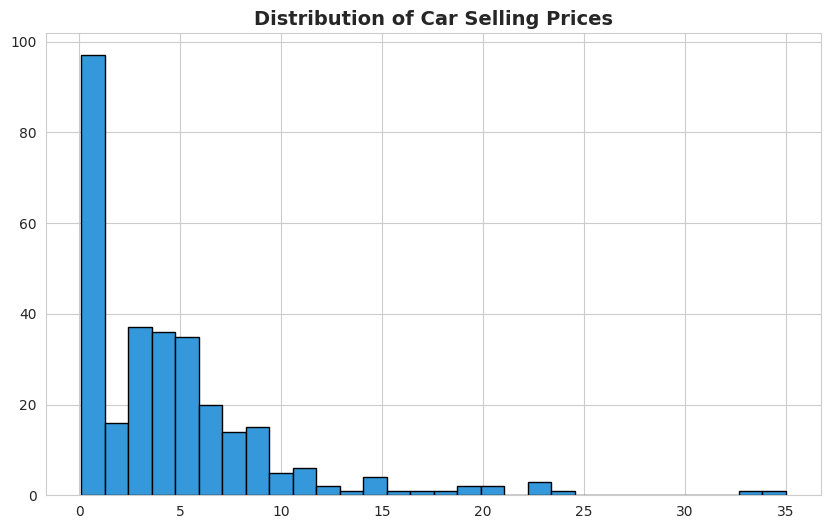

In [10]:
plt.figure(figsize=(10,6))
plt.hist(car_dataset['Selling_Price'],bins=30,color='#3498db',edgecolor='black')
plt.title('Distribution of Car Selling Prices',fontsize=14,fontweight='bold')

Text(0.5, 1.0, 'Feature Correlation Heatmap')

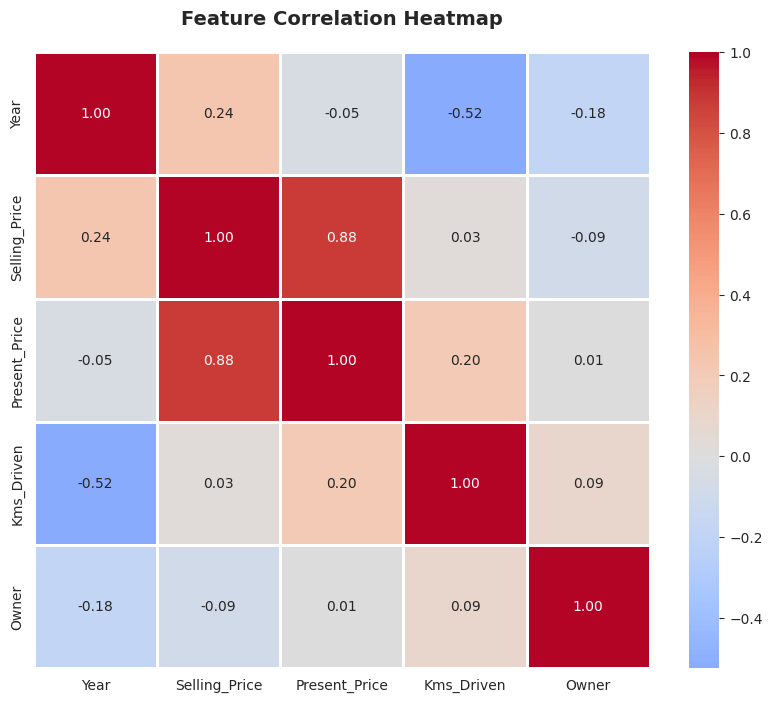

In [17]:
plt.figure(figsize=(10,8))
numeric_data = car_dataset.select_dtypes(include=[np.number])
correlation = numeric_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm',center=0, square=True, linewidths=1, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)

Text(0, 0.5, 'Selling Price (Lakhs)')

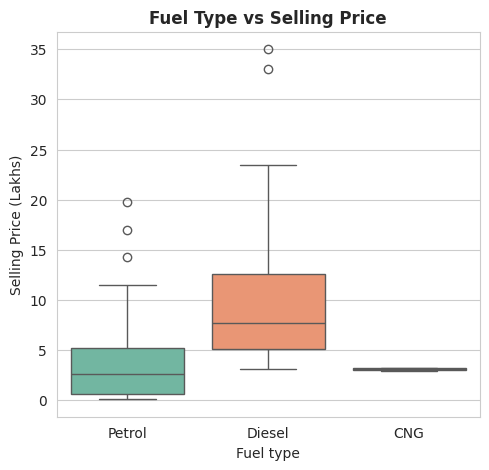

In [20]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.boxplot(x='Fuel_Type',y='Selling_Price',data=car_dataset, palette='Set2')
plt.title('Fuel Type vs Selling Price',fontweight='bold')
plt.xlabel('Fuel type')
plt.ylabel('Selling Price (Lakhs)')